In [1]:
from DecisionTree import DecisionTree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#define helper functions
#function to evaluate model's accuracy
def evaluate_acc(y_true, y_pred):
    total_samples = len(y_true)
    correct_predictions = np.sum(y_true == y_pred)
    return (correct_predictions / total_samples) 

#function to create train test split
def create_train_test_split(x, y, test_ratio):
    n_samples = x.shape[0]

    # shuffle indices
    indices = np.random.permutation(n_samples)

    # compute split point
    test_count = int(n_samples * test_ratio)

    test_idx = indices[:test_count] #get indices for test set
    train_idx = indices[test_count:] #get indices for train set

    #create train and test sets
    x_train = x.iloc[train_idx]
    x_test = x.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]


    return x_train, x_test, y_train, y_test

def plot_decision_boundary(model_class, X, y, max_depth):

    X = X.iloc[:, :2].values
    y = y.values

    model = model_class(max_depth=max_depth)
    model.fit(X, y)

    h = 0.02

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k")

    plt.title("Decision Tree Decision Boundary")
    plt.show()

In [3]:
#load datasets
breast_cancer_df = pd.read_csv(r"data_cleaned\breast_cancer.csv")
hepatitis_df = pd.read_csv(r"data_cleaned\hepatitis.csv")
hepatitis_imputated_df = pd.read_csv(r"data_cleaned\hepatitis_imputed.csv")

#create training and testing sets
#breast cancer dataset
x_bc = breast_cancer_df.drop(columns="diagnosis")
y_bc = breast_cancer_df["diagnosis"]
x_train_bc, x_test_bc, y_train_bc, y_test_bc = create_train_test_split(x_bc, y_bc, 0.2)

#hepatitis dataset
x_hp = hepatitis_df.drop(columns="class")
y_hp = hepatitis_df["class"]
x_train_hp, x_test_hp, y_train_hp, y_test_hp = create_train_test_split(x_hp, y_hp, 0.2)

#hepatitis dataset with imputation
x_hp_imp = hepatitis_imputated_df.drop(columns="class")
y_hp_imp = hepatitis_imputated_df["class"]
x_train_hp_imp, x_test_hp_imp, y_train_hp_imp, y_test_hp_imp = create_train_test_split(x_hp_imp, y_hp_imp, 0.2)

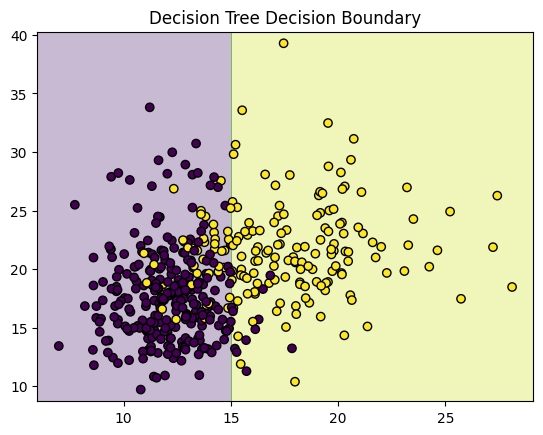

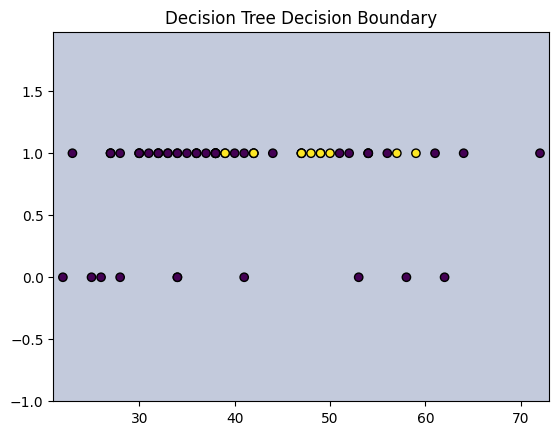

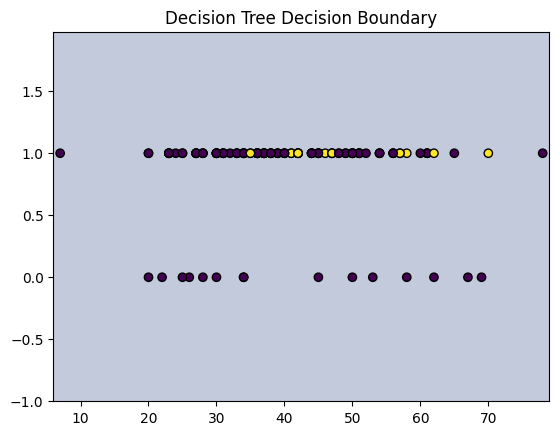

Accuracy of bc_model using max_depth=1: 0.8584070796460177
Accuracy of hp_model using max_depth=1: 0.8125
Accuracy of hp_model_imp using max_depth=1: 0.8709677419354839



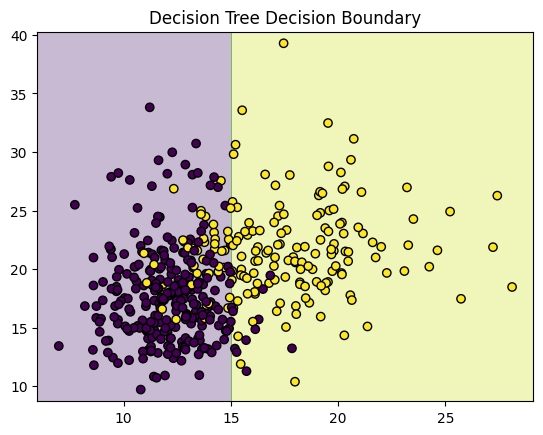

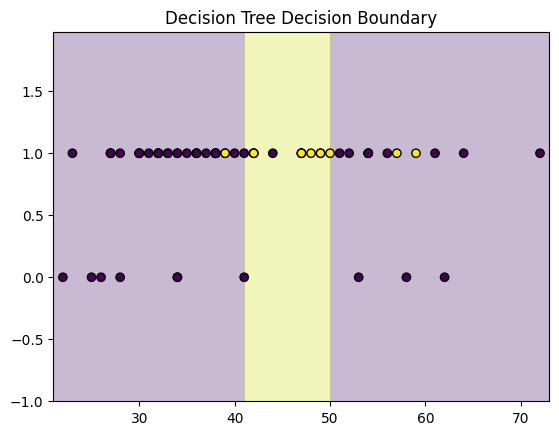

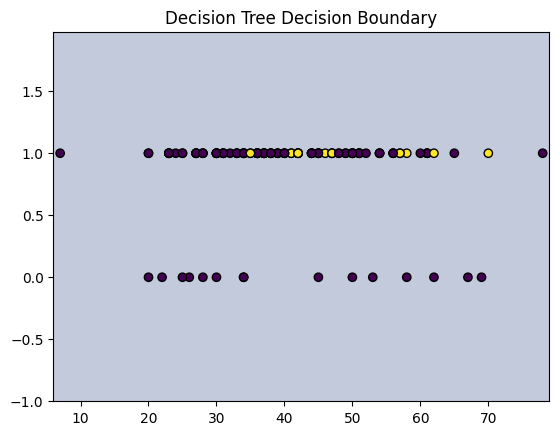

Accuracy of bc_model using max_depth=2: 0.9026548672566371
Accuracy of hp_model using max_depth=2: 0.75
Accuracy of hp_model_imp using max_depth=2: 0.8387096774193549



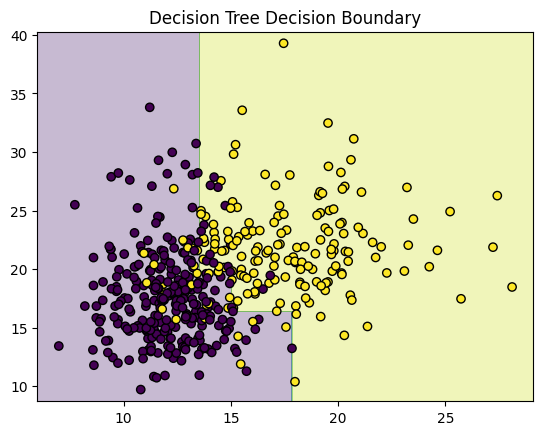

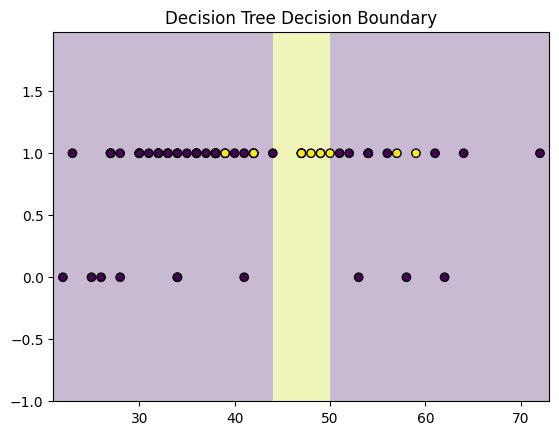

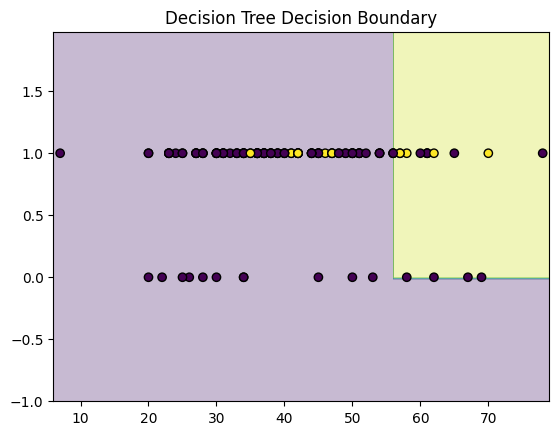

Accuracy of bc_model using max_depth=3: 0.8938053097345132
Accuracy of hp_model using max_depth=3: 0.75
Accuracy of hp_model_imp using max_depth=3: 0.8387096774193549



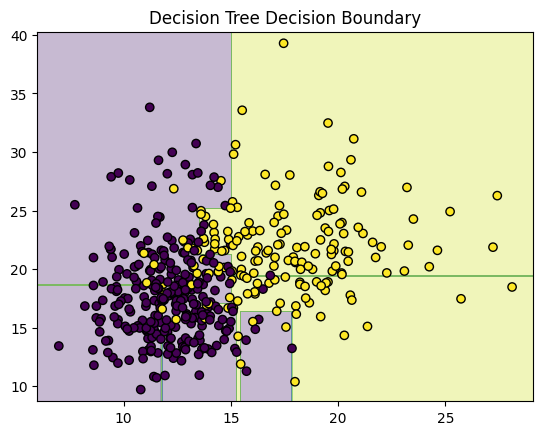

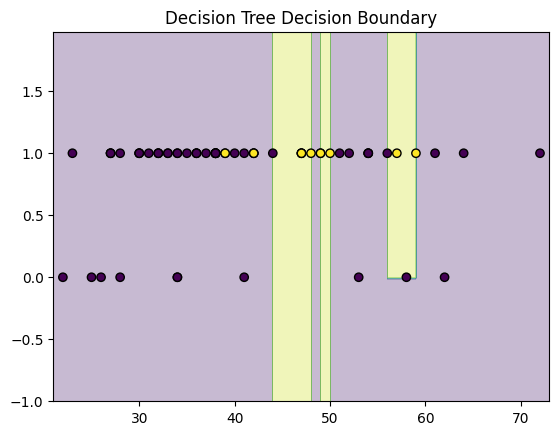

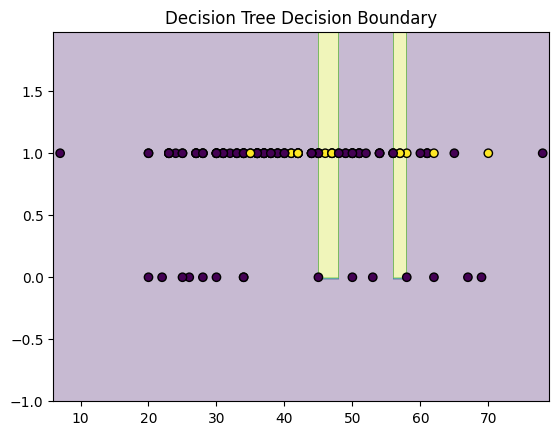

Accuracy of bc_model using max_depth=5: 0.9203539823008849
Accuracy of hp_model using max_depth=5: 0.6875
Accuracy of hp_model_imp using max_depth=5: 0.8064516129032258



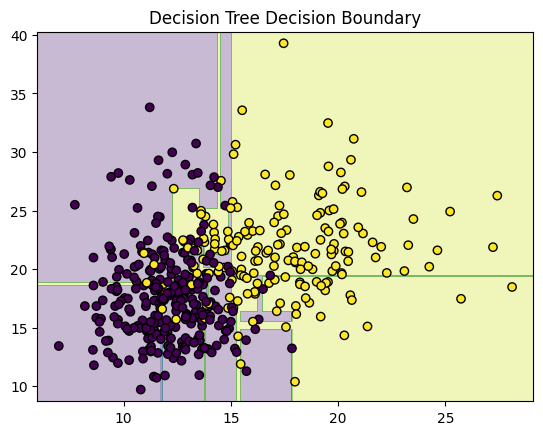

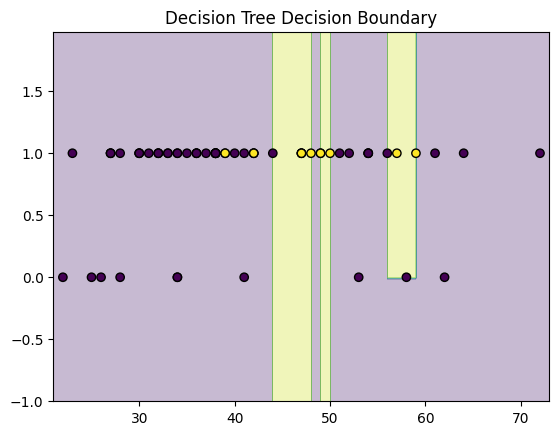

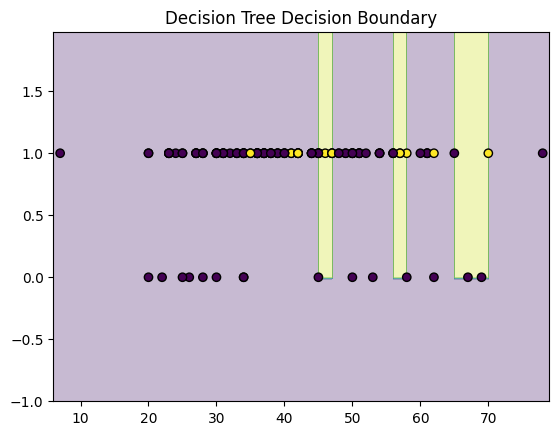

Accuracy of bc_model using max_depth=7: 0.9203539823008849
Accuracy of hp_model using max_depth=7: 0.6875
Accuracy of hp_model_imp using max_depth=7: 0.7741935483870968



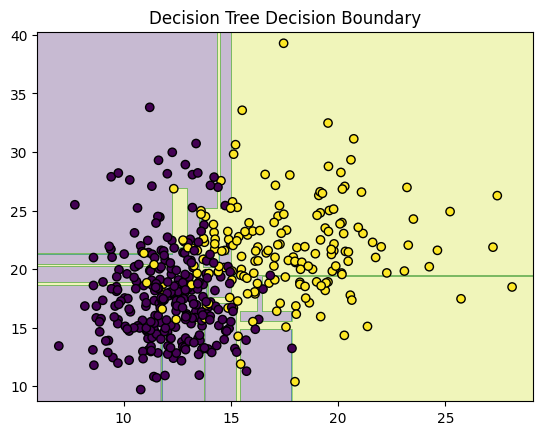

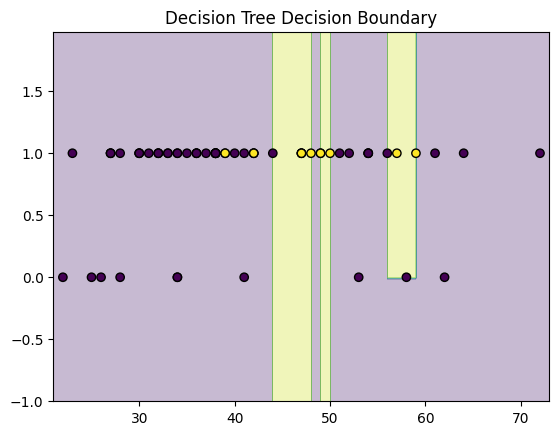

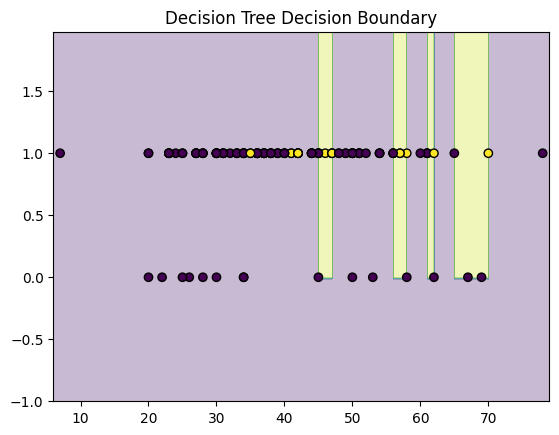

Accuracy of bc_model using max_depth=10: 0.911504424778761
Accuracy of hp_model using max_depth=10: 0.6875
Accuracy of hp_model_imp using max_depth=10: 0.8064516129032258



In [4]:
#Train models
depth_values = [1,2,3,5,7,10]

for depth in depth_values:
    bc_model = DecisionTree(max_depth=depth)
    hp_model = DecisionTree(max_depth=depth)
    hp_model_imp = DecisionTree(max_depth=depth)

    #train the models
    bc_model.fit(x_train_bc,y_train_bc)
    hp_model.fit(x_train_hp, y_train_hp)
    hp_model_imp.fit(x_train_hp_imp, y_train_hp_imp)

    #TO DO plot decision boundary for each model
    plot_decision_boundary(DecisionTree, x_train_bc, y_train_bc, depth)
    plot_decision_boundary(DecisionTree, x_train_hp, y_train_hp, depth)
    plot_decision_boundary(DecisionTree, x_train_hp_imp, y_train_hp_imp, depth)


    #Test
    y_pred_bc = bc_model.predict(x_test_bc)
    y_pred_hp = hp_model.predict(x_test_hp)
    y_pred_hp_imp = hp_model_imp.predict(x_test_hp_imp)

    #Save predictions

    df_bc = pd.DataFrame({
        "y_test": y_test_bc,
        "y_pred": y_pred_bc
    })
    df_bc.to_csv(f"predictions_dt/bc_predictions_max_depth{depth}.csv", index=False)

    df_hp = pd.DataFrame({
        "y_test": y_test_hp,
        "y_pred": y_pred_hp
    })
    df_hp.to_csv(f"predictions_dt/hp_predictions_max_depth{depth}.csv", index=False)

    df_hp_imp = pd.DataFrame({
        "y_test": y_test_hp_imp,
        "y_pred": y_pred_hp_imp
    })
    df_hp_imp.to_csv(f"predictions_dt/hp_imp_predictions_max_depth{depth}.csv", index=False)
    

    #Evaluate
    print(f"Accuracy of bc_model using max_depth={depth}: {evaluate_acc(y_test_bc, y_pred_bc)}")
    print(f"Accuracy of hp_model using max_depth={depth}: {evaluate_acc(y_test_hp, y_pred_hp)}")
    print(f"Accuracy of hp_model_imp using max_depth={depth}: {evaluate_acc(y_test_hp_imp, y_pred_hp_imp)}\n")